# 04 · Diversification, Portfolio Optimisation & an Honest Backtest

**Business question:** *Can we build a better portfolio than the Nifty 50, and does it still work on data it has never seen?*

**Methods**
- **Correlation** and why it drives diversification
- **Modern Portfolio Theory**: expected returns, the covariance matrix, the **efficient frontier**
- **Optimisation** with SciPy (max-Sharpe and minimum-volatility portfolios)
- **Walk-forward backtesting**: the difference between *in-sample* (hindsight) and *out-of-sample* (honest) results

In [1]:
import sys
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

sys.path.append("../src")
from chart_style import apply_style, save, pct_axis, COLORS
import metrics as m
import optimize as opt
apply_style()

con = duckdb.connect(str(Path("..") / "data" / "portfolio.duckdb"), read_only=True)
returns = (con.sql("SELECT date, name, daily_return FROM marts.daily_returns").df()
              .pivot(index="date", columns="name", values="daily_return"))
returns.index = pd.to_datetime(returns.index)
returns = returns.iloc[1:]
BENCH = "Nifty 50 Index"
stocks = returns.drop(columns=BENCH)
sectors = con.sql("SELECT name, sector FROM raw.universe").df().set_index("name")["sector"]

## 1. Correlation: which stocks move together?
**Correlation** runs from −1 (always opposite) to +1 (always together). Diversification works best with **low-correlation** assets.
Sorting the heatmap by sector makes the structure visible.

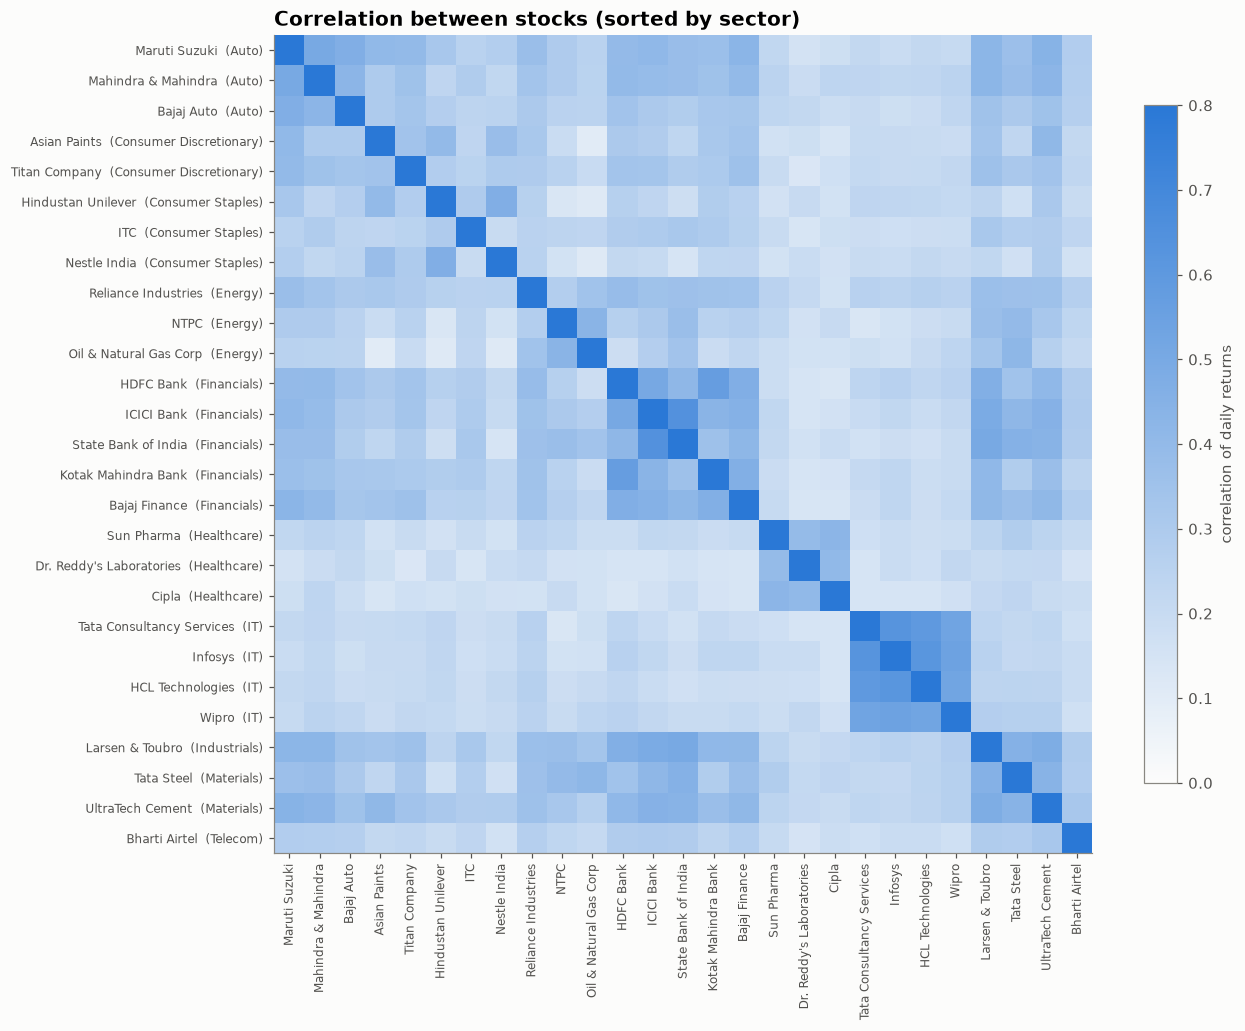

Most correlated pairs:
name           name            
Bharti Airtel  Tata Steel         NaN
               UltraTech Cement   NaN
               Bharti Airtel      NaN

Least correlated pairs:
name                name                  
Asian Paints        Oil & Natural Gas Corp    0.10
Hindustan Unilever  Oil & Natural Gas Corp    0.11
Nestle India        Oil & Natural Gas Corp    0.12


In [2]:
order = sectors.drop(BENCH).sort_values().index
corr = stocks[order].corr()

cmap = LinearSegmentedColormap.from_list("seq", ["#fcfcfb", COLORS["blue"]])
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap=cmap, vmin=0, vmax=0.8)
labels = [f"{n}  ({sectors[n]})" for n in order]
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=8)
ax.set_yticks(range(len(order))); ax.set_yticklabels(labels, fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, label="correlation of daily returns", shrink=0.8)
ax.set_title("Correlation between stocks (sorted by sector)")
save(fig, "14_correlation_heatmap")
plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().sort_values()
print("Most correlated pairs:");  print(pairs.tail(3).round(2).to_string())
print("\nLeast correlated pairs:"); print(pairs.head(3).round(2).to_string())

**Finding:** stocks in the **same sector move together**. The IT block (TCS, Infosys, HCL, Wipro) and the private banks form dark squares (the top pairs are ICICI–SBI 0.64, TCS–Infosys 0.63, Infosys–HCL 0.62). ONGC barely moves with FMCG stocks (~0.1).
**Pharma and FMCG** have low correlation with banks and metals. Owning 4 IT stocks is much less diversified than owning 4 stocks from 4 sectors.

## 2. How many stocks do you need?
Pick *n* stocks at random, weight them equally, and measure the volatility; repeat 500 times for each *n*.

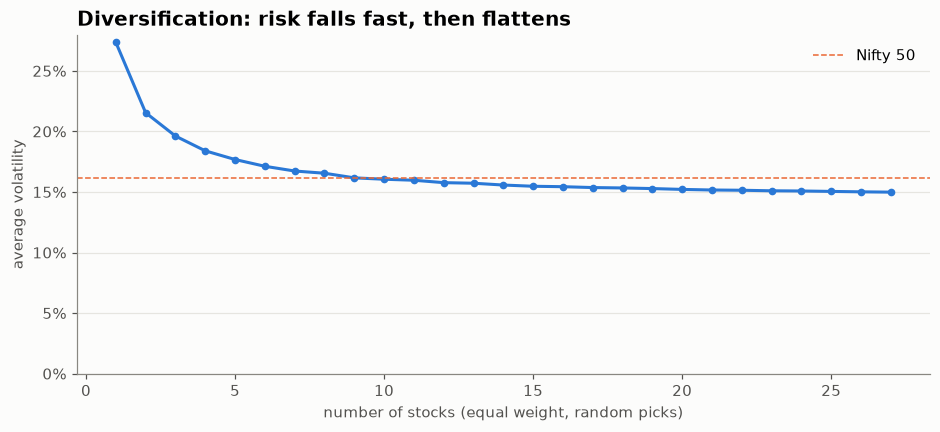

stocks
1     27.4%
5     17.7%
10    16.1%
20    15.2%
27    15.0%
Name: volatility, dtype: str


In [3]:
rng = np.random.default_rng(0)
cols = stocks.columns.to_numpy()
curve = []
for n in range(1, len(cols) + 1):
    vols = [m.volatility(stocks[rng.choice(cols, n, replace=False)].mean(axis=1)) for _ in range(500 if n < len(cols) else 1)]
    curve.append({"stocks": n, "volatility": np.mean(vols)})
curve = pd.DataFrame(curve)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(curve["stocks"], curve["volatility"], color=COLORS["blue"], marker="o", markersize=4)
ax.axhline(m.volatility(returns[BENCH]), color=COLORS["orange"], linestyle="--", linewidth=1, label="Nifty 50")
pct_axis(ax); ax.set_ylim(0)
ax.set_xlabel("number of stocks (equal weight, random picks)"); ax.set_ylabel("average volatility")
ax.set_title("Diversification: risk falls fast, then flattens")
ax.legend()
save(fig, "15_diversification_curve")
plt.show()
print(curve.set_index("stocks").loc[[1, 5, 10, 20, 27], "volatility"].map("{:.1%}".format))

**Finding:** going from 1 to 10 stocks cuts volatility from ~27% to ~16%. After that, extra stocks barely help (~15% at 27).
The remaining risk is **market risk** (systematic risk), which no amount of stock-picking diversifies away.

## 3. Modern Portfolio Theory & the efficient frontier
Each portfolio is a set of **weights** (how much of your money goes into each stock, adding to 100%). For any weights:
- expected return = weighted average of each stock's expected return
- risk = `sqrt(wᵀ Σ w)`, where **Σ (the covariance matrix)** captures how every pair of stocks moves together, which is why correlation matters

The **efficient frontier** is the set of portfolios with the **lowest risk for each level of return**. Nothing rational sits below it.

⚠️ This section uses the **full 10 years** to estimate returns, so it's *hindsight*. We'll test it honestly in section 5.

In [4]:
mu, cov = opt.annualised_inputs(stocks)
cloud = opt.random_portfolios(mu, cov, n=10_000)
frontier = opt.efficient_frontier(mu, cov, points=30, max_weight=1.0)

w_sharpe = opt.max_sharpe_weights(mu, cov, max_weight=0.20)     # cap each stock at 20% (realistic, avoids concentration)
w_minvol = opt.min_vol_weights(mu, cov, max_weight=0.20)
w_equal  = pd.Series(1 / len(mu), index=mu.index)

points = {name: opt.portfolio_stats(w.values, mu, cov) for name, w in
          [("Max-Sharpe", w_sharpe), ("Min-volatility", w_minvol), ("Equal-weight", w_equal)]}
pd.DataFrame(points, index=["expected return", "volatility", "Sharpe"]).T.round(3)

,expected return,volatility,Sharpe
Max-Sharpe,0.251,0.181,1.058
Min-volatility,0.136,0.130,0.582
Equal-weight,0.171,0.150,0.741


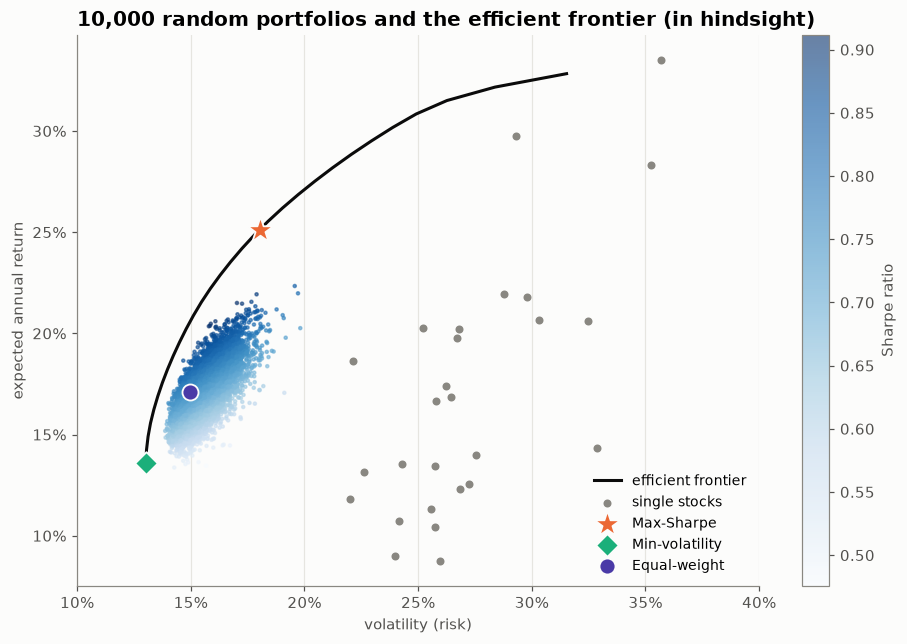

In [5]:
fig, ax = plt.subplots(figsize=(10, 6.5))
sc = ax.scatter(cloud["volatility"], cloud["return"], c=cloud["sharpe"], cmap="Blues", s=4, alpha=0.6)
fig.colorbar(sc, ax=ax, label="Sharpe ratio")
ax.plot(frontier["volatility"], frontier["return"], color="#0b0b0b", linewidth=2, label="efficient frontier")
ax.scatter(np.sqrt(np.diag(cov)), mu, s=18, color=COLORS["grey"], label="single stocks")
markers = {"Max-Sharpe": (COLORS["orange"], "*", 320), "Min-volatility": (COLORS["aqua"], "D", 110), "Equal-weight": (COLORS["violet"], "o", 110)}
for name, (col, mk, size) in markers.items():
    r, v, _ = points[name]
    ax.scatter(v, r, color=col, marker=mk, s=size, edgecolor="#fcfcfb", linewidth=1.2, zorder=4, label=name)
pct_axis(ax, axis="x"); pct_axis(ax, axis="y"); ax.grid(axis="both")
ax.set_xlim(0.1, 0.4)
ax.set_xlabel("volatility (risk)"); ax.set_ylabel("expected annual return")
ax.set_title("10,000 random portfolios and the efficient frontier (in hindsight)")
ax.legend(loc="lower right", fontsize=9)
save(fig, "16_efficient_frontier")
plt.show()

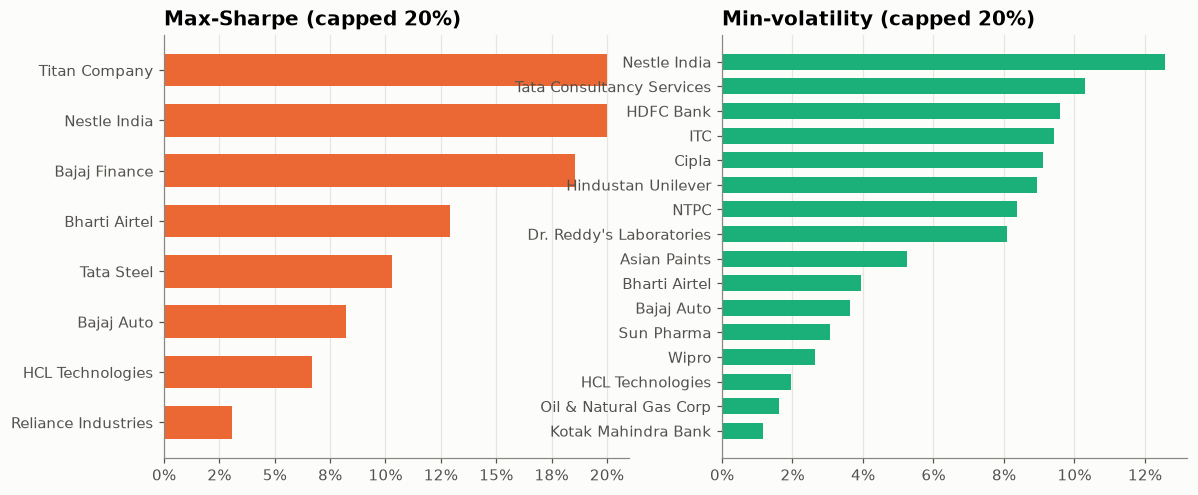

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, w, col) in zip(axes, [("Max-Sharpe (capped 20%)", w_sharpe, COLORS["orange"]), ("Min-volatility (capped 20%)", w_minvol, COLORS["aqua"])]):
    w = w[w > 0.005].sort_values()
    ax.barh(w.index, w.values, color=col, height=0.65)
    pct_axis(ax, axis="x"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.set_title(name)
save(fig, "17_optimal_weights")
plt.show()

**Findings (in hindsight)**
- The **max-Sharpe** portfolio promises **~25% return at ~18% risk (Sharpe ≈ 1.06)**, three times the Nifty's 0.35. It piles into past winners: **Titan, Nestle, Bajaj Finance, Bharti Airtel, Tata Steel**.
- The **min-volatility** portfolio spreads across **defensive, low-correlation** names (Nestle, TCS, HDFC Bank, ITC, Cipla, HUL, NTPC, Dr. Reddy's) for ~13% risk.
- Looks amazing, but the max-Sharpe portfolio was built by **looking at the answers**: it knows which stocks won over the next 10 years. Would anyone have picked these weights in 2016?

## 4. The problem: in-sample vs out-of-sample
An optimiser is very good at **fitting the past**. **In-sample** results (tested on the same data used to build the portfolio) are almost always too good.
The honest test is **out-of-sample**: build the portfolio using only data available at the time, then measure it on the *future*.

### Walk-forward backtest design
- Every **January from 2019**, use the **previous 3 years** of data to choose weights (for 2019: 2016–2018 data only).
- **Hold** those weights for the year and let them drift with prices (no peeking), then repeat next January.
- Charge **0.2% trading cost** on the amount traded at each rebalance.
- Compare 3 strategies (**equal-weight**, **min-volatility**, **max-Sharpe**, all capped at 20% per stock) against the **Nifty 50**.

In [7]:
def walk_forward(strategy, lookback_days=756, max_weight=0.20, cost=0.002, start_year=2019):
    daily, predicted, previous = [], [], None
    for year in range(start_year, returns.index[-1].year + 1):
        train = stocks[stocks.index < f"{year}-01-01"].iloc[-lookback_days:]              # only the past
        test  = stocks[(stocks.index >= f"{year}-01-01") & (stocks.index < f"{year + 1}-01-01")]
        mu_t, cov_t = opt.annualised_inputs(train)
        if strategy == "Equal-weight":
            w = pd.Series(1 / len(mu_t), index=mu_t.index)
        elif strategy == "Min-volatility":
            w = opt.min_vol_weights(mu_t, cov_t, max_weight)
        else:
            w = opt.max_sharpe_weights(mu_t, cov_t, max_weight)
        predicted.append(opt.portfolio_stats(w.values, mu_t, cov_t)[2])               # the Sharpe it *expected*
        year_returns = opt.buy_and_hold(test, w)
        turnover = 1.0 if previous is None else (w - previous).abs().sum()
        year_returns.iloc[0] -= cost * turnover                                            # trading cost
        daily.append(year_returns)
        end_value = (1 + test).prod() * w
        previous = end_value / end_value.sum()                                             # weights after drifting
    return pd.concat(daily), np.mean(predicted)

results, expected_sharpe = {}, {}
for s in ["Equal-weight", "Min-volatility", "Max-Sharpe"]:
    results[s], expected_sharpe[s] = walk_forward(s)
bt = pd.DataFrame(results)
bt[BENCH] = returns.loc[bt.index, BENCH]
print(f"Out-of-sample test period: {bt.index[0].date()} → {bt.index[-1].date()}")

Out-of-sample test period: 2019-01-02 → 2026-09-25


In [8]:
summary = m.summary_table(bt, BENCH)[["CAGR", "Volatility", "Max drawdown", "Sharpe"]]
summary["Sharpe expected in training"] = pd.Series(expected_sharpe)
summary.round(3)

,CAGR,Volatility,Max drawdown,Sharpe,Sharpe expected in training
Equal-weight,0.160,0.157,-0.330,0.660,0.952
Min-volatility,0.140,0.143,-0.290,0.589,0.955
Max-Sharpe,0.128,0.178,-0.347,0.443,1.857
Nifty 50 Index,0.103,0.173,-0.384,0.318,NaN


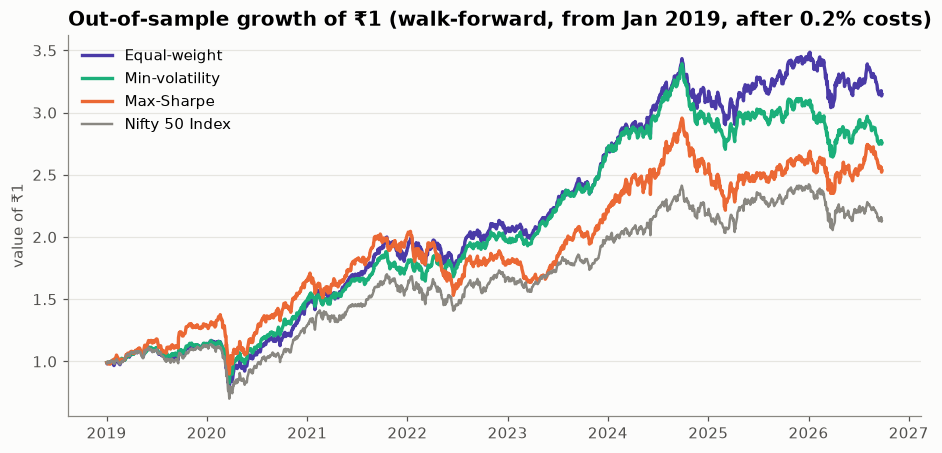

In [9]:
growth = m.growth(bt)
fig, ax = plt.subplots()
for name, col in [("Equal-weight", COLORS["violet"]), ("Min-volatility", COLORS["aqua"]), ("Max-Sharpe", COLORS["orange"]), (BENCH, COLORS["grey"])]:
    ax.plot(growth.index, growth[name], color=col, linewidth=2.2 if name != BENCH else 1.6, label=name)
ax.set_title("Out-of-sample growth of ₹1 (walk-forward, from Jan 2019, after 0.2% costs)")
ax.set_ylabel("value of ₹1")
ax.legend(loc="upper left")
save(fig, "18_backtest_growth")
plt.show()

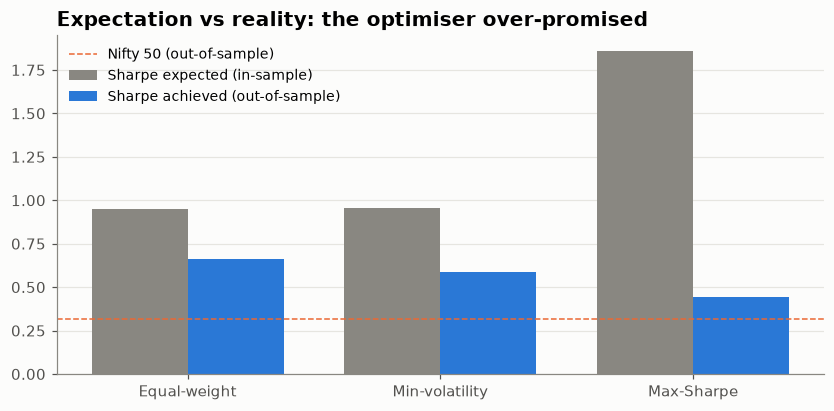

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
names = ["Equal-weight", "Min-volatility", "Max-Sharpe"]
x = np.arange(len(names)); h = 0.38
ax.bar(x - h/2, [expected_sharpe[n] for n in names], h, color=COLORS["grey"], label="Sharpe expected (in-sample)")
ax.bar(x + h/2, [summary.loc[n, "Sharpe"] for n in names], h, color=COLORS["blue"], label="Sharpe achieved (out-of-sample)")
ax.axhline(summary.loc[BENCH, "Sharpe"], color=COLORS["orange"], linestyle="--", linewidth=1, label="Nifty 50 (out-of-sample)")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_title("Expectation vs reality: the optimiser over-promised")
ax.legend(fontsize=9)
save(fig, "19_expected_vs_actual_sharpe")
plt.show()

**Findings: this is the most important result of the project**
- Out of sample, the **max-Sharpe optimiser expected a Sharpe of ~1.9 (on its training data) but delivered only ~0.44**. It was the **worst** of the three strategies. It kept chasing the previous 3 years' winners, which then cooled off.
- **Simple equal-weight** did best on return and risk-adjusted return (**~16% CAGR, Sharpe ~0.66**), a well-known result in finance research: estimating expected returns is so noisy that naive "1/N" diversification often beats optimisation.
- Every strategy fell short of its in-sample promise (equal-weight 0.95 → 0.66, min-vol 0.96 → 0.59), but max-Sharpe fell furthest.
- **Min-volatility** delivered on its main job: **the lowest volatility and the smallest drawdown (~−29% vs −38% for the Nifty)** for a solid ~14% CAGR. Risk (covariance) is much easier to predict than returns.
- All three beat the Nifty (~10% CAGR, Sharpe ~0.32) in this period, but **survivorship bias** (our universe = today's large caps) and the dividend-free benchmark still flatter every strategy. The *ranking* between strategies is the robust lesson, not the absolute outperformance.

---
## Summary: key findings (Diversification & Optimisation)
| # | Finding | So what? |
|---|---|---|
| 1 | Same-sector stocks correlate ~0.5–0.65; FMCG vs energy/metals as low as ~0.1 | Diversify across **sectors**, not just stock count |
| 2 | Volatility falls from ~27% (1 stock) to ~16% (10) to ~15% (27), then flattens | ~10–15 well-spread stocks capture most of the benefit |
| 3 | In hindsight, max-Sharpe promises Sharpe ≈ 1.06 (3× Nifty) | In-sample results look spectacular… |
| 4 | **Out of sample, max-Sharpe expected ~1.9 but delivered ~0.44**, the worst strategy | …but optimisers overfit past returns |
| 5 | Equal-weight: best out-of-sample (Sharpe ~0.66); min-vol: lowest risk and drawdown | Simple, robust rules beat clever fitted ones |
| 6 | Risk is predictable; returns are not | Build portfolios around risk, be humble about return forecasts |

Next: the **interactive dashboard**, where anyone can pick stocks and weights and see the risk metrics live.

In [12]:
con.close()